# Trader Performance vs Bitcoin Sentiment

This notebook looks at whether trader behaviour and outcomes change under different Bitcoin market sentiment conditions.

The two datasets available are:
- Hyperliquid historical trader data
- Bitcoin Fear & Greed Index data

The main idea is simple: attach a sentiment label to each trading day, then compare trading performance across those sentiment regimes.

## 1. Imports and setup

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', lambda x: f'{x:,.4f}')

sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (10, 5)

BASE_DIR = Path.cwd()
OUTPUT_DIR = BASE_DIR / 'notebook_outputs'
OUTPUT_DIR.mkdir(exist_ok=True)

REGIME_ORDER = ['Extreme Fear', 'Fear', 'Neutral', 'Greed', 'Extreme Greed']

## 2. Load the data

First I read both CSV files and take a quick look at their structure.

In [2]:
trades = pd.read_csv(BASE_DIR / 'historical_data.csv')
sentiment = pd.read_csv(BASE_DIR / 'fear_greed_index.csv')

print('Trades shape:', trades.shape)
print('Sentiment shape:', sentiment.shape)

Trades shape: (211224, 16)
Sentiment shape: (2644, 4)


In [3]:
trades.head()

,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.8700,"7,872.1600",BUY,02-12-2024 22:50,0.0000,Buy,0.0000,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.3454,"895,000,000,000,000.0000","1,730,000,000,000.0000"
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.0000,127.6800,BUY,02-12-2024 22:50,986.5246,Buy,0.0000,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.0056,"443,000,000,000,000.0000","1,730,000,000,000.0000"
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.0900,"1,150.6300",BUY,02-12-2024 22:50,"1,002.5190",Buy,0.0000,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.0504,"660,000,000,000,000.0000","1,730,000,000,000.0000"
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.9800,"1,142.0400",BUY,02-12-2024 22:50,"1,146.5586",Buy,0.0000,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.0500,"1,080,000,000,000,000.0000","1,730,000,000,000.0000"
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.7300,69.7500,BUY,02-12-2024 22:50,"1,289.4885",Buy,0.0000,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.0031,"1,050,000,000,000,000.0000","1,730,000,000,000.0000"


In [4]:
sentiment.head()

,timestamp,value,classification,date
0,1517463000,30,Fear,2018-02-01
1,1517549400,15,Extreme Fear,2018-02-02
2,1517635800,40,Fear,2018-02-03
3,1517722200,24,Extreme Fear,2018-02-04
4,1517808600,11,Extreme Fear,2018-02-05


## 3. Understand the columns

Before cleaning anything, it helps to check data types and missing values.

In [5]:
trades.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 211224 entries, 0 to 211223
Data columns (total 16 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Account           211224 non-null  object 
 1   Coin              211224 non-null  object 
 2   Execution Price   211224 non-null  float64
 3   Size Tokens       211224 non-null  float64
 4   Size USD          211224 non-null  float64
 5   Side              211224 non-null  object 
 6   Timestamp IST     211224 non-null  object 
 7   Start Position    211224 non-null  float64
 8   Direction         211224 non-null  object 
 9   Closed PnL        211224 non-null  float64
 10  Transaction Hash  211224 non-null  object 
 11  Order ID          211224 non-null  int64  
 12  Crossed           211224 non-null  bool   
 13  Fee               211224 non-null  float64
 14  Trade ID          211224 non-null  float64
 15  Timestamp         211224 non-null  float64
dtypes: bool(1), float64(

In [6]:
sentiment.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2644 entries, 0 to 2643
Data columns (total 4 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   timestamp       2644 non-null   int64 
 1   value           2644 non-null   int64 
 2   classification  2644 non-null   object
 3   date            2644 non-null   object
dtypes: int64(2), object(2)
memory usage: 82.8+ KB


In [7]:
trades.isna().sum().sort_values(ascending=False)

Account             0
Coin                0
Execution Price     0
Size Tokens         0
Size USD            0
Side                0
Timestamp IST       0
Start Position      0
Direction           0
Closed PnL          0
Transaction Hash    0
Order ID            0
Crossed             0
Fee                 0
Trade ID            0
Timestamp           0
dtype: int64

In [8]:
sentiment.isna().sum()

timestamp         0
value             0
classification    0
date              0
dtype: int64

## 4. Clean the trading data

The trade file mixes numeric and text columns, so I convert the fields needed for analysis.

I also parse the trade timestamp and create a calendar date column, because the sentiment data is daily.

In [9]:
numeric_cols = [
    'Execution Price',
    'Size Tokens',
    'Size USD',
    'Start Position',
    'Closed PnL',
    'Fee',
    'Timestamp'
]

for col in numeric_cols:
    trades[col] = pd.to_numeric(trades[col], errors='coerce')

trades['Timestamp IST'] = pd.to_datetime(
    trades['Timestamp IST'],
    format='%d-%m-%Y %H:%M',
    errors='coerce'
)

trades['date'] = trades['Timestamp IST'].dt.normalize()

trades[['Timestamp IST', 'date']].head()

,Timestamp IST,date
0,2024-12-02 22:50:00,2024-12-02
1,2024-12-02 22:50:00,2024-12-02
2,2024-12-02 22:50:00,2024-12-02
3,2024-12-02 22:50:00,2024-12-02
4,2024-12-02 22:50:00,2024-12-02


In [10]:
trades[numeric_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
Execution Price,"211,224.0000","11,414.7233","29,447.6549",0.0000,4.8547,18.2800,101.5800,"109,004.0000"
Size Tokens,"211,224.0000","4,623.3650","104,272.8895",0.0000,2.9400,32.0000,187.9025,"15,822,438.0000"
Size USD,"211,224.0000","5,639.4512","36,575.1385",0.0000,193.7900,597.0450,"2,058.9600","3,921,430.7200"
Start Position,"211,224.0000","-29,946.2488","673,807.4237","-14,334,629.0000",-376.2311,84.7279,"9,337.2775","30,509,482.0000"
Closed PnL,"211,224.0000",48.7490,919.1648,"-117,990.1041",0.0000,0.0000,5.7928,"135,329.0901"
Fee,"211,224.0000",1.1640,6.7589,-1.1757,0.0161,0.0896,0.3938,837.4716
Timestamp,"211,224.0000","1,737,744,290,421.5430","8,689,920,301.5900","1,680,000,000,000.0000","1,740,000,000,000.0000","1,740,000,000,000.0000","1,740,000,000,000.0000","1,750,000,000,000.0000"


## 5. Clean the sentiment data

In [11]:
sentiment['date'] = pd.to_datetime(sentiment['date'], errors='coerce')
sentiment['classification'] = pd.Categorical(
    sentiment['classification'],
    categories=REGIME_ORDER,
    ordered=True
)

sentiment[['date', 'value', 'classification']].head()

,date,value,classification
0,2018-02-01,30,Fear
1,2018-02-02,15,Extreme Fear
2,2018-02-03,40,Fear
3,2018-02-04,24,Extreme Fear
4,2018-02-05,11,Extreme Fear


In [12]:
sentiment['classification'].value_counts().reindex(REGIME_ORDER)

classification
Extreme Fear     508
Fear             781
Neutral          396
Greed            633
Extreme Greed    326
Name: count, dtype: int64

## 6. Check date overlap

This matters because there is no point joining the datasets if their date ranges do not overlap properly.

In [13]:
print('Trade date range   :', trades['date'].min(), 'to', trades['date'].max())
print('Sentiment date range:', sentiment['date'].min(), 'to', sentiment['date'].max())

Trade date range   : 2023-05-01 00:00:00 to 2025-05-01 00:00:00
Sentiment date range: 2018-02-01 00:00:00 to 2025-05-02 00:00:00


## 7. Merge both datasets

The join is done on calendar date. Each trade gets the sentiment label of the day it happened.

In [14]:
df = trades.merge(
    sentiment[['date', 'value', 'classification']],
    on='date',
    how='left'
).copy()

df['net_pnl'] = df['Closed PnL'] - df['Fee']
df['is_profitable'] = df['net_pnl'] > 0
df['has_realized_pnl'] = df['Closed PnL'] != 0
df['size_usd_safe'] = df['Size USD'].replace(0, np.nan)
df['roi_proxy'] = df['net_pnl'] / df['size_usd_safe']

df.head()

,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp,date,value,classification,net_pnl,is_profitable,has_realized_pnl,size_usd_safe,roi_proxy
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.8700,"7,872.1600",BUY,2024-12-02 22:50:00,0.0000,Buy,0.0000,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.3454,"895,000,000,000,000.0000","1,730,000,000,000.0000",2024-12-02,80.0000,Extreme Greed,-0.3454,False,False,"7,872.1600",-0.0000
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.0000,127.6800,BUY,2024-12-02 22:50:00,986.5246,Buy,0.0000,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.0056,"443,000,000,000,000.0000","1,730,000,000,000.0000",2024-12-02,80.0000,Extreme Greed,-0.0056,False,False,127.6800,-0.0000
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.0900,"1,150.6300",BUY,2024-12-02 22:50:00,"1,002.5190",Buy,0.0000,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.0504,"660,000,000,000,000.0000","1,730,000,000,000.0000",2024-12-02,80.0000,Extreme Greed,-0.0504,False,False,"1,150.6300",-0.0000
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.9800,"1,142.0400",BUY,2024-12-02 22:50:00,"1,146.5586",Buy,0.0000,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.0500,"1,080,000,000,000,000.0000","1,730,000,000,000.0000",2024-12-02,80.0000,Extreme Greed,-0.0500,False,False,"1,142.0400",-0.0000
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.7300,69.7500,BUY,2024-12-02 22:50:00,"1,289.4885",Buy,0.0000,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.0031,"1,050,000,000,000,000.0000","1,730,000,000,000.0000",2024-12-02,80.0000,Extreme Greed,-0.0031,False,False,69.7500,-0.0000


In [15]:
df['classification'].isna().sum()

np.int64(6)

Only a very small number of trades are unmatched, so the merge coverage is strong enough for analysis.

## 8. Quick high-level checks

In [16]:
summary_snapshot = {
    'rows': len(df),
    'accounts': df['Account'].nunique(),
    'coins': df['Coin'].nunique(),
    'first_trade_day': df['date'].min(),
    'last_trade_day': df['date'].max()
}

summary_snapshot

{'rows': 211224,
 'accounts': 32,
 'coins': 246,
 'first_trade_day': Timestamp('2023-05-01 00:00:00'),
 'last_trade_day': Timestamp('2025-05-01 00:00:00')}

## 9. Regime-level performance table

Now I group by sentiment regime and compare the main performance measures.

In [17]:
regime_summary = (
    df[df['classification'].notna()]
    .groupby('classification', observed=True)
    .agg(
        trades=('Account', 'size'),
        active_days=('date', 'nunique'),
        active_accounts=('Account', 'nunique'),
        total_volume_usd=('Size USD', 'sum'),
        total_closed_pnl=('Closed PnL', 'sum'),
        total_fees=('Fee', 'sum'),
        total_net_pnl=('net_pnl', 'sum'),
        avg_net_pnl=('net_pnl', 'mean'),
        median_net_pnl=('net_pnl', 'median'),
        positive_trade_rate=('is_profitable', 'mean'),
        realized_trade_share=('has_realized_pnl', 'mean'),
        mean_roi_proxy=('roi_proxy', 'mean')
    )
    .reset_index()
)

regime_summary['positive_trade_rate'] = regime_summary['positive_trade_rate'] * 100
regime_summary['realized_trade_share'] = regime_summary['realized_trade_share'] * 100
regime_summary['net_pnl_to_volume'] = (
    regime_summary['total_net_pnl'] / regime_summary['total_volume_usd']
)

regime_summary.sort_values('total_net_pnl', ascending=False)

,classification,trades,active_days,active_accounts,total_volume_usd,total_closed_pnl,total_fees,total_net_pnl,avg_net_pnl,median_net_pnl,positive_trade_rate,realized_trade_share,mean_roi_proxy,net_pnl_to_volume
1,Fear,61837,91,32,"483,324,789.7900","3,357,155.4416","92,456.9487","3,264,698.4930",52.7952,-0.0058,41.1517,48.2041,0.0149,0.0068
4,Extreme Greed,39992,114,30,"124,465,164.5700","2,715,171.3107","27,030.6655","2,688,140.6452",67.2170,-0.0011,46.7694,52.1429,0.0398,0.0216
3,Greed,50303,193,31,"288,582,494.7200","2,150,129.2730","63,098.6920","2,087,030.5810",41.4892,-0.0105,39.1249,50.0487,0.0194,0.0072
2,Neutral,37686,67,31,"180,242,063.0800","1,292,920.6756","39,374.2683","1,253,546.4072",33.2629,-0.0075,39.5903,48.1850,0.0095,0.0070
0,Extreme Fear,21400,14,32,"114,484,261.4400","739,110.2485","23,888.6339","715,221.6146",33.4216,-0.0060,36.8458,48.6262,0.0041,0.0062


A useful detail here is that total profit and efficiency are not the same thing. One regime can make more total money simply because there were more trades, while another can look stronger on a per-trade or per-dollar basis.

## 10. Visual comparison by sentiment regime

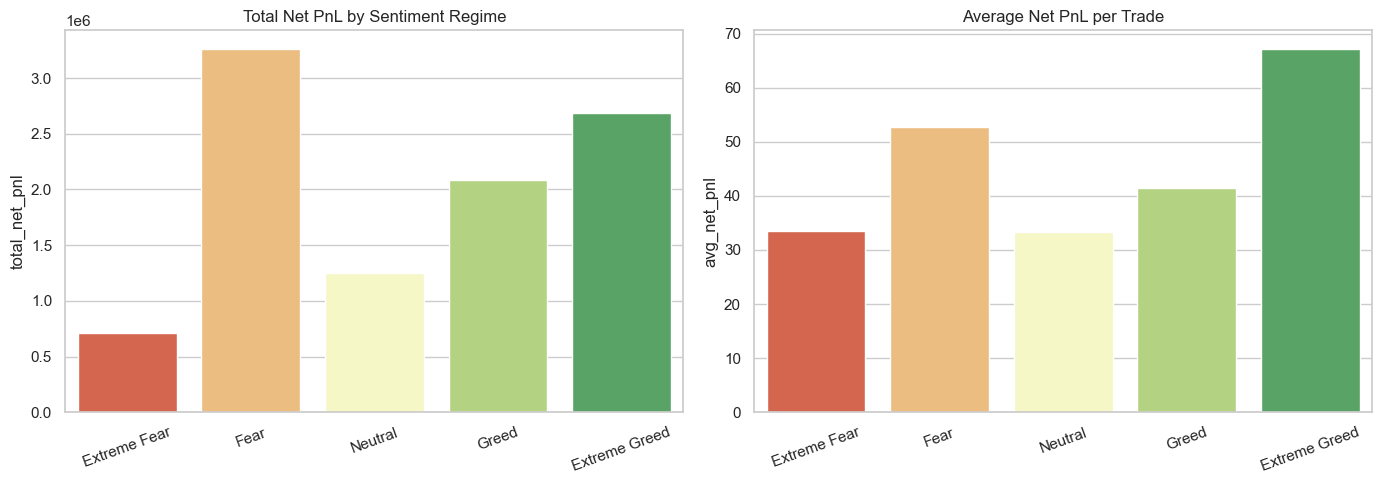

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.barplot(
    data=regime_summary,
    x='classification',
    y='total_net_pnl',
    hue='classification',
    order=REGIME_ORDER,
    palette='RdYlGn',
    legend=False,
    ax=axes[0]
)
axes[0].set_title('Total Net PnL by Sentiment Regime')
axes[0].set_xlabel('')
axes[0].tick_params(axis='x', rotation=20)

sns.barplot(
    data=regime_summary,
    x='classification',
    y='avg_net_pnl',
    hue='classification',
    order=REGIME_ORDER,
    palette='RdYlGn',
    legend=False,
    ax=axes[1]
)
axes[1].set_title('Average Net PnL per Trade')
axes[1].set_xlabel('')
axes[1].tick_params(axis='x', rotation=20)

plt.tight_layout()
plt.show()

## 11. Day-level behaviour

Trade-level results are useful, but daily aggregation gives a cleaner view of consistency.

In [19]:
daily_summary = (
    df[df['classification'].notna()]
    .groupby(['date', 'classification'], observed=True)
    .agg(
        daily_net_pnl=('net_pnl', 'sum'),
        daily_volume_usd=('Size USD', 'sum'),
        daily_trades=('Account', 'size'),
        daily_accounts=('Account', 'nunique')
    )
    .reset_index()
)

daily_regime_stats = (
    daily_summary
    .groupby('classification', observed=True)
    .agg(
        days=('date', 'nunique'),
        avg_daily_net_pnl=('daily_net_pnl', 'mean'),
        median_daily_net_pnl=('daily_net_pnl', 'median'),
        profitable_day_rate=('daily_net_pnl', lambda s: (s > 0).mean() * 100),
        avg_daily_trades=('daily_trades', 'mean')
    )
    .reset_index()
)

daily_regime_stats

,classification,days,avg_daily_net_pnl,median_daily_net_pnl,profitable_day_rate,avg_daily_trades
0,Extreme Fear,14,"51,087.2582","21,159.9303",64.2857,"1,528.5714"
1,Fear,91,"35,875.8076","1,308.4536",71.4286,679.5275
2,Neutral,67,"18,709.6479","1,565.0865",67.1642,562.4776
3,Greed,193,"10,813.6300",608.2564,69.4301,260.6373
4,Extreme Greed,114,"23,580.1811","3,050.3573",86.8421,350.8070


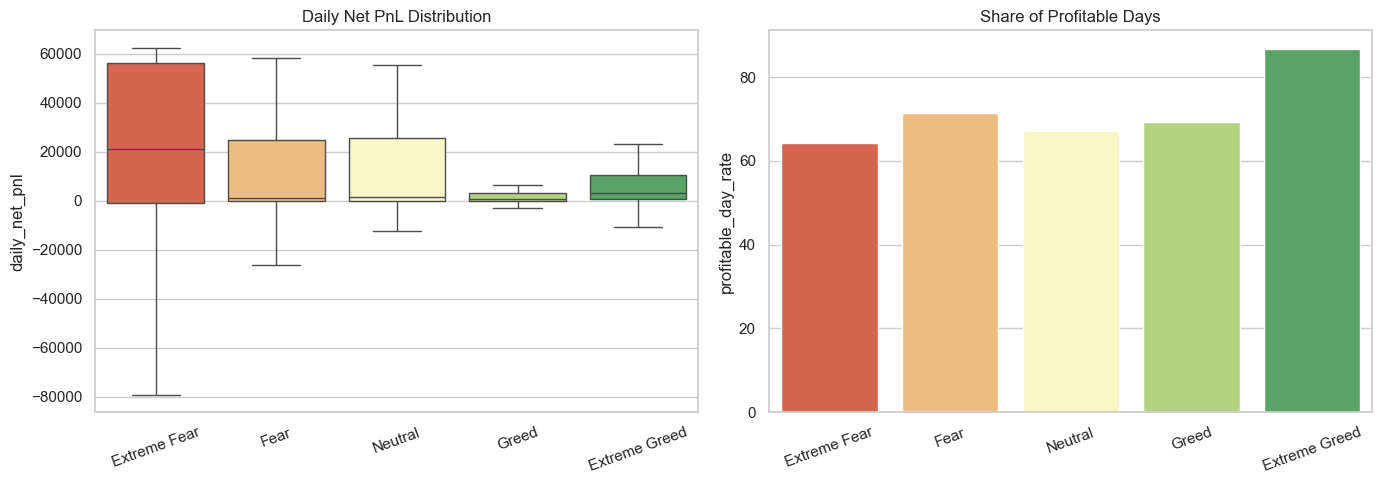

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.boxplot(
    data=daily_summary,
    x='classification',
    y='daily_net_pnl',
    hue='classification',
    order=REGIME_ORDER,
    palette='RdYlGn',
    legend=False,
    showfliers=False,
    ax=axes[0]
)
axes[0].set_title('Daily Net PnL Distribution')
axes[0].set_xlabel('')
axes[0].tick_params(axis='x', rotation=20)

sns.barplot(
    data=daily_regime_stats,
    x='classification',
    y='profitable_day_rate',
    hue='classification',
    order=REGIME_ORDER,
    palette='RdYlGn',
    legend=False,
    ax=axes[1]
)
axes[1].set_title('Share of Profitable Days')
axes[1].set_xlabel('')
axes[1].tick_params(axis='x', rotation=20)

plt.tight_layout()
plt.show()

## 12. Which accounts perform best?

Looking only at regime averages hides the fact that different accounts may behave very differently.

In [21]:
account_regime = (
    df[df['classification'].notna()]
    .groupby(['Account', 'classification'], observed=True)
    .agg(
        trades=('Account', 'size'),
        total_net_pnl=('net_pnl', 'sum'),
        avg_net_pnl=('net_pnl', 'mean'),
        avg_size_usd=('Size USD', 'mean'),
        positive_trade_rate=('is_profitable', 'mean')
    )
    .reset_index()
)

account_regime['positive_trade_rate'] = account_regime['positive_trade_rate'] * 100
account_regime.head()

,Account,classification,trades,total_net_pnl,avg_net_pnl,avg_size_usd,positive_trade_rate
0,0x083384f897ee0f19899168e3b1bec365f52a9012,Extreme Fear,100,"124,625.2294","1,246.2523","15,071.0086",37.0000
1,0x083384f897ee0f19899168e3b1bec365f52a9012,Fear,1778,"1,110,127.7018",624.3688,"17,020.4949",52.6434
2,0x083384f897ee0f19899168e3b1bec365f52a9012,Neutral,421,"124,348.9686",295.3657,"23,336.9993",58.1948
3,0x083384f897ee0f19899168e3b1bec365f52a9012,Greed,574,"275,800.9173",480.4894,"15,134.1304",16.0279
4,0x083384f897ee0f19899168e3b1bec365f52a9012,Extreme Greed,945,"-42,078.3095",-44.5273,"12,080.2706",6.6667


In [22]:
account_overview = (
    account_regime
    .groupby('Account', observed=True)
    .agg(
        total_trades=('trades', 'sum'),
        total_net_pnl=('total_net_pnl', 'sum')
    )
    .reset_index()
    .sort_values('total_net_pnl', ascending=False)
)

account_overview.head(10)

,Account,total_trades,total_net_pnl
27,0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23,14733,"2,127,387.2794"
0,0x083384f897ee0f19899168e3b1bec365f52a9012,3818,"1,592,824.5077"
29,0xbaaaf6571ab7d571043ff1e313a9609a10637864,21192,"931,567.1006"
31,0xbee1707d6b44d4d52bfe19e41f8a828645437aab,40184,"822,727.6534"
13,0x513b8629fe877bb581bf244e326a047b249c4ff1,12236,"763,997.9123"
11,0x4acb90e786d897ecffb614dc822eb231b4ffb9f4,4356,"669,721.0582"
15,0x72743ae2822edd658c0c50608fd7c5c501b2afbd,1590,"427,804.1286"
9,0x430f09841d65beb3f27765503d0f850b8bce7713,1237,"415,794.8654"
17,0x75f7eeb85dc639d5e99c78f95393aa9a5f1170d4,9893,"376,500.1476"
16,0x72c6a4624e1dffa724e6d00d64ceae698af892a0,1424,"360,258.0112"


## 13. Regime sensitivity by account

This step checks whether some traders are noticeably stronger in one sentiment regime than another.

In [23]:
eligible_accounts = account_regime.groupby('Account')['trades'].sum()
eligible_accounts = eligible_accounts[eligible_accounts >= 250].index

account_regime_filtered = account_regime[account_regime['Account'].isin(eligible_accounts)].copy()

account_pivot = (
    account_regime_filtered
    .pivot(index='Account', columns='classification', values='total_net_pnl')
    .reindex(columns=REGIME_ORDER)
    .fillna(0)
)

account_regime_rank = pd.DataFrame({
    'best_regime': account_pivot.idxmax(axis=1),
    'worst_regime': account_pivot.idxmin(axis=1),
    'specialization_gap': account_pivot.max(axis=1) - account_pivot.min(axis=1)
}).reset_index()

account_regime_rank.sort_values('specialization_gap', ascending=False).head(10)

,Account,best_regime,worst_regime,specialization_gap
0,0x083384f897ee0f19899168e3b1bec365f52a9012,Fear,Extreme Greed,"1,152,206.0113"
27,0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23,Extreme Greed,Extreme Fear,"1,094,825.5466"
29,0xbaaaf6571ab7d571043ff1e313a9609a10637864,Fear,Extreme Greed,"615,230.4984"
19,0x8170715b3b381dffb7062c0298972d4727a0a63b,Fear,Greed,"511,584.5346"
15,0x72743ae2822edd658c0c50608fd7c5c501b2afbd,Greed,Fear,"511,375.1922"
31,0xbee1707d6b44d4d52bfe19e41f8a828645437aab,Extreme Greed,Neutral,"453,130.1851"
13,0x513b8629fe877bb581bf244e326a047b249c4ff1,Neutral,Extreme Fear,"439,579.2238"
30,0xbd5fead7180a9c139fa51a103cb6a2ce86ddb5c3,Fear,Neutral,"325,995.7801"
11,0x4acb90e786d897ecffb614dc822eb231b4ffb9f4,Fear,Extreme Greed,"272,883.6378"
9,0x430f09841d65beb3f27765503d0f850b8bce7713,Greed,Extreme Fear,"227,343.9670"


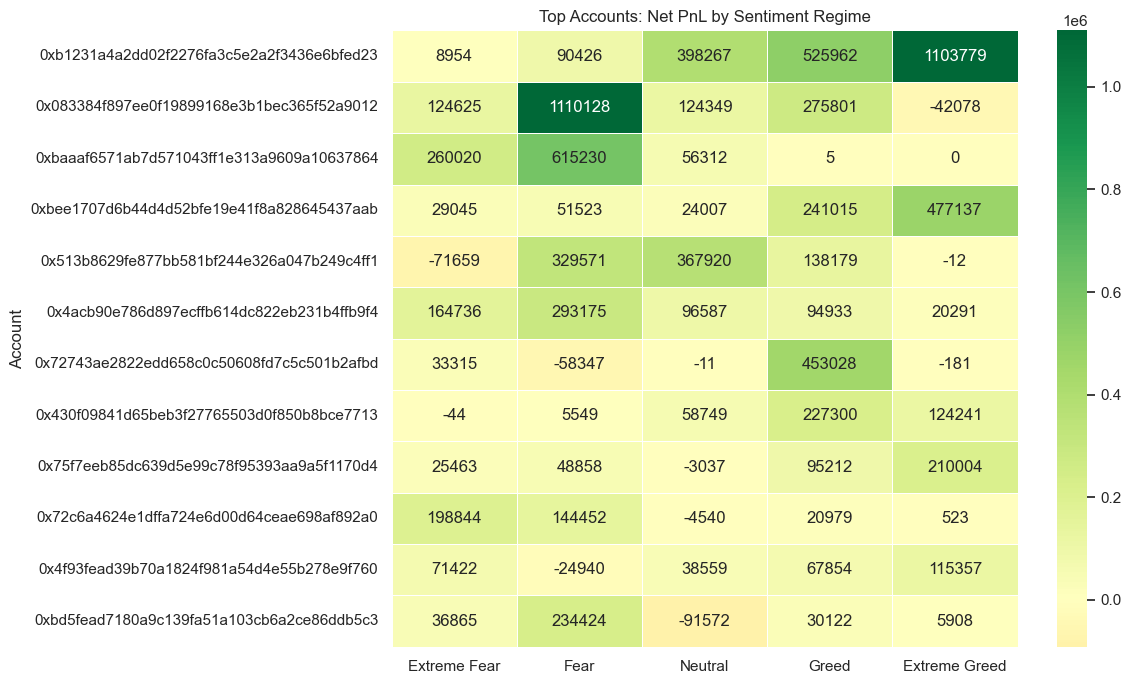

In [24]:
top_accounts = account_overview.head(12)['Account']
heatmap_data = account_pivot.loc[top_accounts]

plt.figure(figsize=(12, 7))
sns.heatmap(
    heatmap_data,
    cmap='RdYlGn',
    center=0,
    annot=True,
    fmt='.0f',
    linewidths=0.5
)
plt.title('Top Accounts: Net PnL by Sentiment Regime')
plt.xlabel('')
plt.ylabel('Account')
plt.tight_layout()
plt.show()

## 14. Which coins contributed most in each regime?

In [25]:
coin_regime = (
    df[df['classification'].notna()]
    .groupby(['Coin', 'classification'], observed=True)
    .agg(
        trades=('Coin', 'size'),
        total_net_pnl=('net_pnl', 'sum'),
        total_volume_usd=('Size USD', 'sum')
    )
    .reset_index()
)

top_coin_by_regime = (
    coin_regime
    .sort_values(['classification', 'total_net_pnl'], ascending=[True, False])
    .groupby('classification', observed=True)
    .head(5)
)

top_coin_by_regime

,Coin,classification,trades,total_net_pnl,total_volume_usd
372,HYPE,Extreme Fear,10278,"477,947.4551","29,253,178.6900"
310,ETH,Extreme Fear,1393,"272,941.7703","7,720,053.0800"
583,SOL,Extreme Fear,1878,"99,108.9087","26,241,359.7800"
449,MELANIA,Extreme Fear,446,"97,251.6157","862,551.9200"
599,SUI,Extreme Fear,249,"44,449.2869","1,318,482.1100"
373,HYPE,Fear,27951,"828,971.6443","63,327,528.2700"
584,SOL,Fear,3914,"730,044.2943","51,824,505.6500"
311,ETH,Fear,2850,"668,900.8635","39,635,351.1000"
263,BTC,Fear,9870,"424,930.8143","300,912,163.3000"
450,MELANIA,Fear,1985,"196,486.6815","3,477,530.6400"


## 15. Main takeaways

After going through the data, these are the points that stand out most:

1. `Fear` generates the highest total net PnL overall.
2. `Extreme Greed` looks strongest on efficiency and consistency, especially on average net PnL per trade and profitable-day rate.
3. Median trade-level PnL is slightly negative across all regimes, which suggests that a smaller number of large winners drive a lot of the final profit.
4. Different accounts clearly perform better in different sentiment environments.
5. A few coins dominate the profit contribution in each regime, so regime analysis and asset selection should probably be looked at together.

## 16. Caveats

- The Fear & Greed Index is daily, so it cannot capture intraday sentiment changes.
- The sentiment proxy is Bitcoin-specific, while the trade data includes many different assets.
- `Extreme Fear` appears on relatively few overlap days, so those results should be treated more carefully.

## 17. Save key outputs

This final step saves the main summary tables in case I want to attach them separately.

In [26]:
regime_summary.to_csv(OUTPUT_DIR / 'regime_summary.csv', index=False)
daily_regime_stats.to_csv(OUTPUT_DIR / 'daily_regime_stats.csv', index=False)
account_overview.to_csv(OUTPUT_DIR / 'account_overview.csv', index=False)
account_regime_rank.to_csv(OUTPUT_DIR / 'account_regime_rank.csv', index=False)
top_coin_by_regime.to_csv(OUTPUT_DIR / 'top_coin_by_regime.csv', index=False)

print('Saved files to:', OUTPUT_DIR)

Saved files to: c:\Users\Rohith Syam\Documents\Internships\PrimeTrade_Ai\ai intern\notebook_outputs
